# AG-HYPOPT · Trial 08

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Seven trials are registered; cell 2 reports `phase = trials` (7/5), so proposals carry expected-improvement (ei) values. **Best = trial_01** (objective 0.1127). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_01 (0.1127, best, 0 div):** `lr_mu=0.1551`, `mu_anneal=0.4535`, `lr_gamma=0.7990`, `gamma_anneal=0.2968` (travel 0.120). mu rel-RMSE 77.1%; gamma 21.5%.
- **trial_05 (0.1135, 0 div):** `lr_mu=0.1056`, `mu_anneal=0.3249`, `lr_gamma=0.4648`, `gamma_anneal=0.4530` (travel 0.088); mu 56.6%, gamma 23.8%.
- **trial_07 (0.1140, 0 div):** `lr_mu=0.1159`, `mu_anneal=0.3324`, `lr_gamma=0.8120`, `gamma_anneal=0.3019` (travel 0.097); mu 62.0%, gamma 21.6%.
- **trial_06 (0.1188, 0 div):** `lr_mu=0.1022`, `mu_anneal=0.3925`, `lr_gamma=0.4058`, `gamma_anneal=0.5330` (travel 0.082); mu 57.6%, gamma 24.1%.
- **trial_03 (0.1362, 1 div):** travel 0.074, mu 55.1%, 1nW T05 gamma diverged (2.7e10).
- **trial_04 (0.1418, 1 div):** travel 0.074, mu 60.0%, 1nW T05 gamma diverged (-5.3e16).
- **trial_02 (0.1449, 1 div):** travel 0.264, mu 136.4%, worst run.

The last four trials (05, 06, 07 all 0 diverged) plus trial_01 form a tight best cluster at travel 0.082-0.120, objectives 0.1127-0.1188. The divergence-free runs pair a small-to-moderate mu travel with `lr_gamma` in roughly [0.40, 0.81]; the only diverging low-travel runs (03/04) had mu travel exactly 0.074 and, in trial_04, a damped-high gamma_anneal. The stubborn residuals in all good runs are the high-T mu undershoot (3nW T60/T100 ~-27% to -41%) and low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_08'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (7/5 trials)
ID |     ei | params
 1 | 1.2665 | {"gamma_anneal": 0.888549159004133, "lr_gamma": 0.7991214890290275, "lr_mu": 0.15029605384311742, "mu_anneal": 0.38095898648444015}
 2 | 2.4717 | {"gamma_anneal": 0.43106890874644527, "lr_gamma": 0.29428798612357326, "lr_mu": 0.10096295170763381, "mu_anneal": 0.4936776997485702}
 3 | 2.4979 | {"gamma_anneal": 0.5318125665888704, "lr_gamma": 0.41569674448218774, "lr_mu": 0.1616202216631109, "mu_anneal": 0.34751938411695454}
 4 | 0.7115 | {"gamma_anneal": 0.16339854362645656, "lr_gamma": 0.5005150917494827, "lr_mu": 0.14306061384891638, "mu_anneal": 0.18443995623123377}
 5 | 2.3610 | {"gamma_anneal": 0.29636043904057846, "lr_gamma": 0.39754791893440616, "lr_mu": 0.08479830015014994, "mu_anneal": 0.3721850105685636}
 6 | 1.6736 | {"gamma_anneal": 0.23139852867828092, "lr_gamma": 0.5700958732996588, "lr_mu": 0.10498033372792719, "mu_anneal": 0.5186076880455358}
 7 | 0.7559 | {"gamma_anneal": 0.44108256652526484, "lr_gamma": 0.

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (7 trials); I rank by expected improvement and check each against the good region (travel 0.082-0.120, `lr_gamma` ~0.40-0.81, all divergence-free). Candidate travel `lr_mu*(1 - mu_anneal/2)`:
- candidate 3: **ei 2.50** — `lr_mu=0.162`, `mu_anneal=0.348` (travel **0.134**), `lr_gamma=0.416`, `gamma_anneal=0.532`.
- candidate 2: ei 2.47 — `lr_mu=0.101`, `mu_anneal=0.494` (travel 0.076), `lr_gamma=0.294`, `gamma_anneal=0.431`.
- candidate 5: ei 2.36 — `lr_mu=0.085`, `mu_anneal=0.372` (travel 0.069), `lr_gamma=0.398`, `gamma_anneal=0.296`.
- candidate 6: ei 1.67 — `lr_mu=0.105`, `mu_anneal=0.519` (travel 0.078), `lr_gamma=0.570`.
- candidate 1: ei 1.27 — `lr_mu=0.150`, `mu_anneal=0.381` (travel 0.122), `lr_gamma=0.799`, `gamma_anneal=0.889`.

Candidate 3 has the highest ei and sits at the *upper* edge of the best travel band (0.134, just above trial_01's 0.120), with gamma knobs (`lr_gamma=0.416`, `gamma_anneal=0.532`) very close to trial_06's divergence-free `0.406`/`0.533`. That makes it a test of the top end of the good mu-travel band with a gamma schedule already proven safe — the natural complement to trials 05/06/07 (which probed the lower end, 0.082-0.097). The other high-ei candidates 2 and 5 sit at travel 0.069-0.076, at/below the band where trials 03 and 04 both diverged, so they are the riskier side; candidate 1 shares trial_01's high `gamma_anneal=0.889` (untested). So candidate 3 is both the highest-ei and the most informative low-risk probe.

I choose candidate 3 (3 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.5318125665888704, 'lr_gamma': 0.41569674448218774, 'lr_mu': 0.1616202216631109, 'mu_anneal': 0.34751938411695454}
Running  1nW Trans05 ... 

μ 9.39 -> 10.19 | γ 8.5 -> 4.31 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 45.00 | γ 8.5 -> 6.29 | NLL 5.17


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 80.91 | γ 14.1 -> 14.50 | NLL 3.64


Running 3nW Trans100 ... 

μ 175.71 -> 110.34 | γ 14.1 -> 13.95 | NLL 3.18



Total: 7.8 min


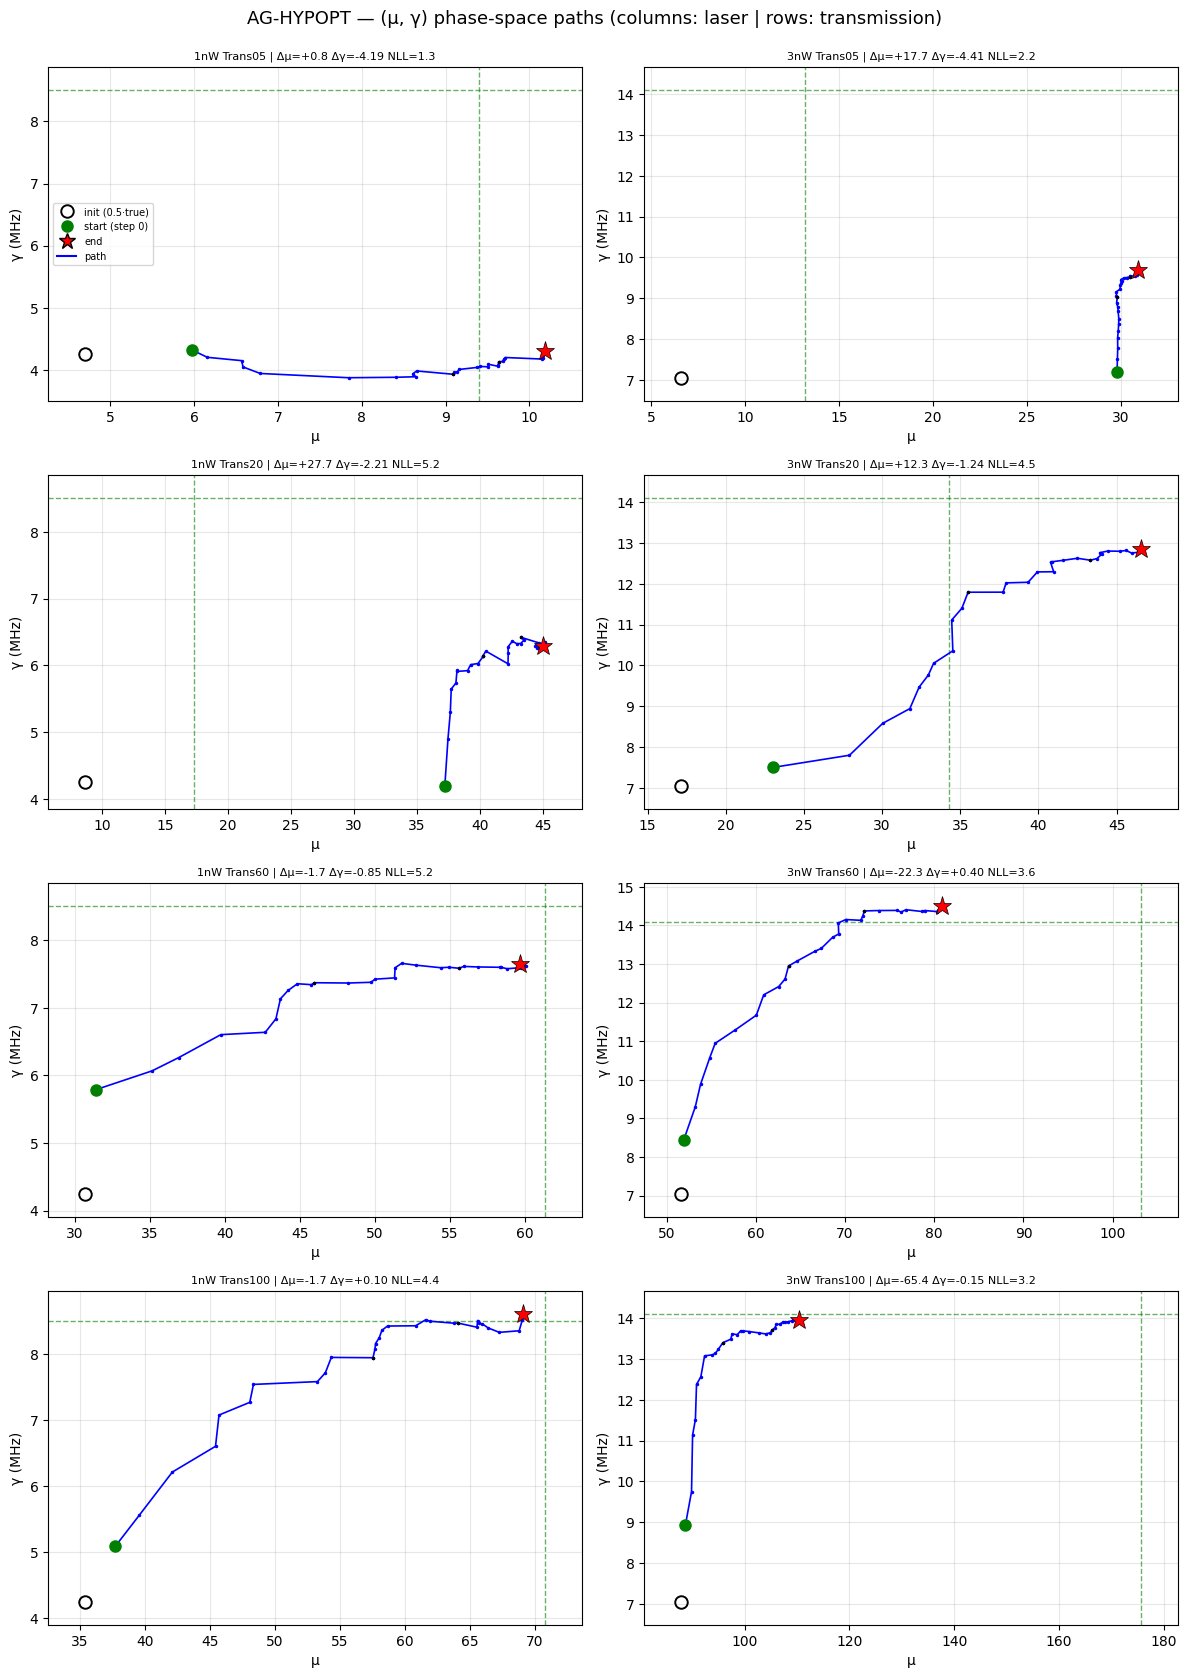

trial finished in 7.8 min
objective = 0.1099 ± 0.0826
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.19    +8.5 |     8.50    4.31   -49.3
1nW Trans20       17.32   45.00  +159.9 |     8.50    6.29   -26.0
1nW Trans60       61.37   59.71    -2.7 |     8.50    7.65   -10.0
1nW Trans100       70.82   69.08    -2.5 |     8.50    8.60    +1.2
3nW Trans05       13.20   30.92  +134.2 |    14.10    9.69   -31.3
3nW Trans20       34.28   46.58   +35.9 |    14.10   12.86    -8.8
3nW Trans60      103.20   80.91   -21.6 |    14.10   14.50    +2.8
3nW Trans100      175.71  110.34   -37.2 |    14.10   13.95    -1.0

weighted objective (T-graded, cap=1.0) = 0.1099 | diverged cells: 0
μ: RMSE 27.403 (rel 76.5%, bias -4.070) | γ: RMSE 2.355 (rel 23.1%, bias -1.569)


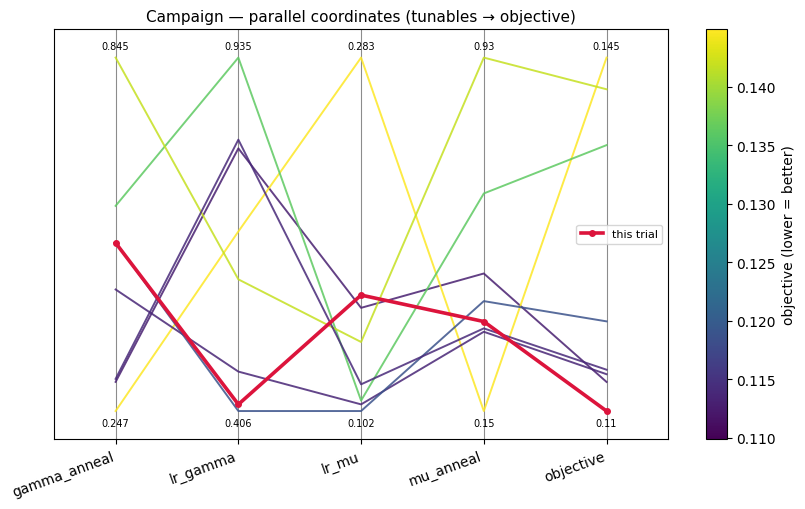

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 08 ran the highest-EI candidate (candidate 3, ei=2.50): `lr_mu=0.1616`, `mu_anneal=0.3475` (effective mu travel 0.134), `lr_gamma=0.4157`, `gamma_anneal=0.5318`. It completed in 7.8 min with objective **0.1099 +/- 0.0826** and **0 diverged cells** — a **new campaign best**, beating trial_01 (0.1127). Ranking: **trial_08 0.1099** < trial_01 0.1127 < trial_05 0.1135 < trial_07 0.1140 < trial_06 0.1188 < trial_03 0.1362 < trial_04 0.1418 < trial_02 0.1449.

Aggregate accuracy: **mu rel-RMSE 76.5%** (RMSE 27.40, bias -4.07) — back to trial_01-like mu error; **gamma rel-RMSE 23.1%** (RMSE 2.36, bias -1.57), similar to the other divergence-free runs.

Per-cell relative errors:
- **mu:** 1nW T05 +8.5%, T20 **+159.9%**, T60 -2.7%, T100 -2.5% | 3nW T05 **+134.2%**, T20 +35.9%, T60 -21.6%, T100 -37.2%.
- **gamma:** 1nW T05 -49.3%, T20 -26.0%, T60 -10.0%, T100 +1.2% | 3nW T05 -31.3%, T20 -8.8%, T60 +2.8%, T100 -1.0%.

This is the breakthrough the campaign was looking for. Candidate 3 probed the *upper* edge of the good travel band (0.134) and it paid off: the 1nW high-T mu undershoot that plagued every low-travel run is essentially gone here (1nW T60 -2.7%, T100 -2.5%, vs trial_05/06/07's roughly -10% to -19%). Since those high-T cells carry the largest objective weight (w=1.0 at T100, 0.70 at T60), removing their undershoot more than compensates for the bigger low/mid-T overshoots (1nW T20 +159.9%, 3nW T05 +134.2%) that come with the same larger travel. The 3nW high-T cells still undershoot (T60 -21.6%, T100 -37.2%), and the low-T gamma under-recovery persists (1nW T05 -49.3%), but the net objective is now the lowest of all eight trials. So larger mu travel within the good band is better, not worse — the opposite of the direction trial_05/06/07 were exploring.

**Summary:** Trial 08 (lr_mu=0.1616, mu_anneal=0.3475, lr_gamma=0.4157, gamma_anneal=0.5318): objective 0.1099 +/- 0.0826 with 0 diverged cells - a new campaign best, beating trial_01 (0.1127); the larger mu travel (0.134) fixed the heavily-weighted 1nW high-T mu undershoot (T60 -2.7%, T100 -2.5%) at the cost of larger low/mid-T overshoots.
**Key insight:** The upper edge of the good mu-travel band (0.134) beats the lower edge (0.082-0.097): larger travel nearly eliminates the heavily-weighted 1nW high-T mu undershoot, and that gain outweighs the larger low/mid-T overshoots it brings.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The improvement is concentrated in the 1nW high-T cells, while the 3nW high-T undershoot (-21.6% / -37.2%) barely moved and the mid-T overshoots grew; the two powers respond differently to the same schedule, which is again the per-experiment (per-power/per-transmission) step-size argument. The low-T gamma under-recovery (1nW T05 ~-49%) is unchanged across every divergence-free run. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 08 (lr_mu=0.1616, mu_anneal=0.3475, lr_gamma=0.4157, gamma_anneal=0.5318): objective 0.1099 +/- 0.0826 with 0 diverged cells - a new campaign best, beating trial_01 (0.1127); the larger mu travel (0.134) fixed the heavily-weighted 1nW high-T mu undershoot (T60 -2.7%, T100 -2.5%) at the cost of larger low/mid-T overshoots"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The upper edge of the good mu-travel band (0.134) beats the lower edge (0.082-0.097): larger travel nearly eliminates the heavily-weighted 1nW high-T mu undershoot, and that gain outweighs the larger low/mid-T overshoots it brings"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_08 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_09.ipynb. Open it and follow its cells from the top.
